𝐏𝐫𝐨𝐛𝐥𝐞𝐦 𝐒𝐭𝐚𝐭𝐞𝐦𝐞𝐧𝐭-
Brands struggle to identify what content, sentiment, and timing drive real engagement on social media. 
This project analyzes multi-platform data to uncover engagement drivers, optimize posting strategies, 
and manage brand reputation by detecting negative buzz.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [33]:
!pip install wordcloud


In [34]:
from wordcloud import WordCloud
import re

In [35]:
from sklearn.model_selection import train_test_split


In [36]:
df=pd.read_csv("Social Media Engagement Dataset.csv")

In [37]:
df.shape

(12000, 28)

In [38]:
df.dtypes

post_id                     object
timestamp                   object
day_of_week                 object
platform                    object
user_id                     object
location                    object
language                    object
text_content                object
hashtags                    object
mentions                    object
keywords                    object
topic_category              object
sentiment_score            float64
sentiment_label             object
emotion_type                object
toxicity_score             float64
likes_count                  int64
shares_count                 int64
comments_count               int64
impressions                  int64
engagement_rate            float64
brand_name                  object
product_name                object
campaign_name               object
campaign_phase              object
user_past_sentiment_avg    float64
user_engagement_growth     float64
buzz_change_rate           float64
dtype: object

In [39]:
df.isnull().sum()


post_id                       0
timestamp                     0
day_of_week                   0
platform                      0
user_id                       0
location                      0
language                      0
text_content                  0
hashtags                      0
mentions                   3941
keywords                      0
topic_category                0
sentiment_score               0
sentiment_label               0
emotion_type                  0
toxicity_score                0
likes_count                   0
shares_count                  0
comments_count                0
impressions                   0
engagement_rate               0
brand_name                    0
product_name                  0
campaign_name                 0
campaign_phase                0
user_past_sentiment_avg       0
user_engagement_growth        0
buzz_change_rate              0
dtype: int64

In [40]:
df.describe()

,sentiment_score,toxicity_score,likes_count,shares_count,comments_count,impressions,engagement_rate,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
count,12000.000000,12000.000000,12000.00000,12000.000000,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,0.000553,0.503868,2490.72025,1007.167167,504.34575,49811.338500,0.278137,0.001472,0.000998,0.729692
std,0.583563,0.288198,1441.53253,575.072282,288.68416,28930.289451,1.149206,0.576627,0.289940,57.787219
min,-0.999800,0.000000,0.00000,0.000000,0.00000,130.000000,0.001880,-0.999600,-0.499900,-99.900000
25%,-0.503200,0.251400,1236.00000,510.000000,253.00000,24716.500000,0.049100,-0.495975,-0.248400,-48.700000
50%,-0.006200,0.505950,2496.00000,1018.000000,503.00000,49674.000000,0.080605,0.001950,0.002800,0.900000
75%,0.513525,0.756200,3723.25000,1501.000000,755.00000,74815.000000,0.163123,0.501725,0.250700,50.100000
max,0.999900,0.999900,5000.00000,2000.000000,1000.00000,99997.000000,32.211710,0.999400,0.499900,99.900000


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   post_id                  12000 non-null  object 
 1   timestamp                12000 non-null  object 
 2   day_of_week              12000 non-null  object 
 3   platform                 12000 non-null  object 
 4   user_id                  12000 non-null  object 
 5   location                 12000 non-null  object 
 6   language                 12000 non-null  object 
 7   text_content             12000 non-null  object 
 8   hashtags                 12000 non-null  object 
 9   mentions                 8059 non-null   object 
 10  keywords                 12000 non-null  object 
 11  topic_category           12000 non-null  object 
 12  sentiment_score          12000 non-null  float64
 13  sentiment_label          12000 non-null  object 
 14  emotion_type          

In [42]:
df["mentions"]= df["mentions"].fillna('No Mention')

In [43]:
df["timestamp"]=pd.to_datetime(df["timestamp"],errors='coerce')

In [44]:
df['year'] = df['timestamp'].dt.year
df['hour'] = df['timestamp'].dt.hour
df['date'] = df['timestamp'].dt.date
df['day_of_week'] = df['timestamp'].dt.day_name()




In [45]:
df.isnull().sum()

post_id                       0
timestamp                  7265
day_of_week                7265
platform                      0
user_id                       0
location                      0
language                      0
text_content                  0
hashtags                      0
mentions                      0
keywords                      0
topic_category                0
sentiment_score               0
sentiment_label               0
emotion_type                  0
toxicity_score                0
likes_count                   0
shares_count                  0
comments_count                0
impressions                   0
engagement_rate               0
brand_name                    0
product_name                  0
campaign_name                 0
campaign_phase                0
user_past_sentiment_avg       0
user_engagement_growth        0
buzz_change_rate              0
year                       7265
hour                       7265
date                       7265
dtype: i

In [46]:
#Recalculate engagement_rate
df['engagement_rate_calc'] = ((df['likes_count'] + df['shares_count'] + df['comments_count']) / df['impressions']) * 100

𝐄𝐱𝐩𝐥𝐨𝐫𝐚𝐭𝐨𝐫𝐲 𝐃𝐚𝐭𝐚 𝐀𝐧𝐚𝐥𝐲𝐬𝐢𝐬 (𝐄𝐃𝐀)


Which platform gives highest engagement rate?

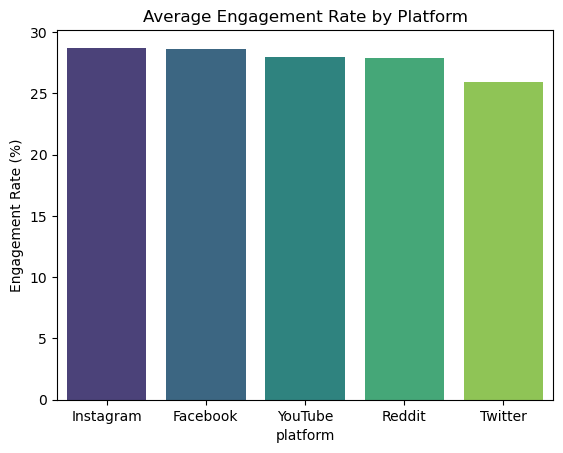

<Figure size 1000x600 with 0 Axes>

In [47]:
Engagement_by_platform=df.groupby('platform')['engagement_rate_calc'].mean().sort_values(ascending=False)
sns.barplot(x=Engagement_by_platform.index, y=Engagement_by_platform.values,hue=Engagement_by_platform.index,palette="viridis",legend=False)
plt.title("Average Engagement Rate by Platform")
plt.ylabel("Engagement Rate (%)")
plt.figure(figsize=(10,6))
plt.show()

𝗔𝘃𝗲𝗿𝗮𝗴𝗲 𝗘𝗻𝗴𝗮𝗴𝗲𝗺𝗲𝗻𝘁 𝗥𝗮𝘁𝗲 𝗯𝘆 𝗣𝗹𝗮𝘁𝗳𝗼𝗿𝗺
Instagram and Facebook lead in engagement (≈29%).
Twitter lags behind (≈26%), suggesting it may not be the most effective channel for driving interactions.
YouTube and Reddit sit in the middle, showing steady but slightly lower engagement than Instagram/Facebook.

Does posting day/time matter?

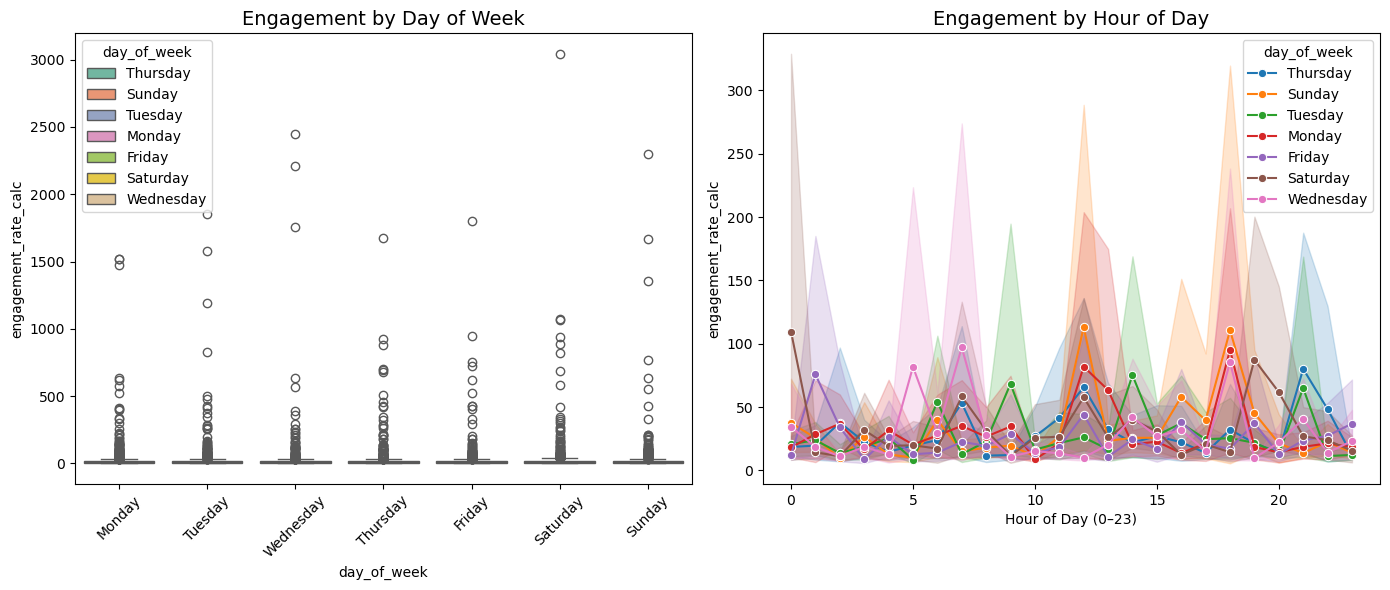

In [48]:
plt.figure(figsize=(14, 6))
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]


# Engagement by Day of Week (Boxplot)
plt.subplot(1, 2, 1)
sns.boxplot(x="day_of_week", y="engagement_rate_calc",hue="day_of_week",data=df,order=order, palette="Set2",legend=True)
        
plt.title("Engagement by Day of Week", fontsize=14)
plt.xticks(rotation=45)

# Engagement by Hour of Day (Lineplot)
plt.subplot(1, 2, 2)
sns.lineplot(x="hour", y="engagement_rate_calc",hue="day_of_week", data=df, marker="o", color="steelblue",legend=True)
plt.title("Engagement by Hour of Day", fontsize=14)
plt.xlabel("Hour of Day (0–23)")

plt.tight_layout()
plt.show()

𝗘𝗻𝗴𝗮𝗴𝗲𝗺𝗲𝗻𝘁 𝗯𝘆 𝗗𝗮𝘆 𝗼𝗳 𝗪𝗲𝗲𝗸 & 𝗘𝗻𝗴𝗮𝗴𝗲𝗺𝗲𝗻𝘁 𝗯𝘆 𝗛𝗼𝘂𝗿 𝗼𝗳 𝗗𝗮𝘆
Engagement is spread across all days, but some days (like Thursday & Sunday) show higher peaks, meaning campaigns can go viral depending on content.Clear peaks are visible around morning (9–11 AM), afternoon (3–5 PM), and evening (8–10 PM).

Engagement Trend by campaign phase.
Which campaign phase works best?

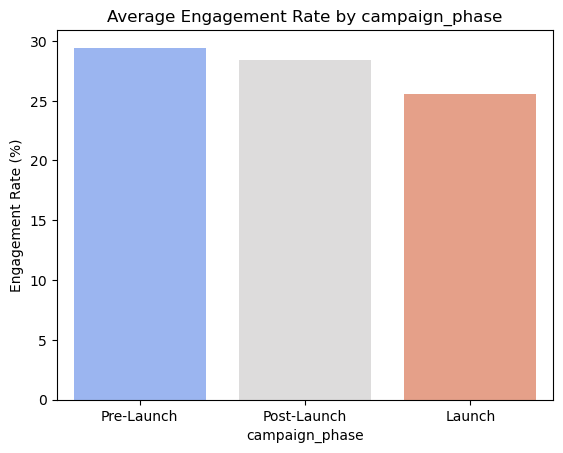

<Figure size 1000x600 with 0 Axes>

In [49]:
campaign_phase_Engag=df.groupby('campaign_phase')['engagement_rate_calc'].mean().sort_values(ascending=False)
sns.barplot(x=campaign_phase_Engag.index, y=campaign_phase_Engag.values,hue=campaign_phase_Engag.index,palette="coolwarm",legend=False)
plt.title("Average Engagement Rate by campaign_phase")
plt.ylabel("Engagement Rate (%)")
plt.figure(figsize=(10,6))
plt.show()

𝗔𝘃𝗲𝗿𝗮𝗴𝗲 𝗘𝗻𝗴𝗮𝗴𝗲𝗺𝗲𝗻𝘁 𝗥𝗮𝘁𝗲 𝗯𝘆 𝗖𝗮𝗺𝗽𝗮𝗶𝗴𝗻 𝗣𝗵𝗮𝘀𝗲
𝗣𝗿𝗲-𝗟𝗮𝘂𝗻𝗰𝗵 campaigns have the highest engagement (~29.5%).
𝗣𝗼𝘀𝘁-𝗟𝗮𝘂𝗻𝗰𝗵 maintains good momentum (~28%), but slightly lower.
𝗟𝗮𝘂𝗻𝗰𝗵 𝗽𝗵𝗮𝘀𝗲 has the lowest engagement (~26%), showing that hype is stronger before and after launch rather than during the launch.

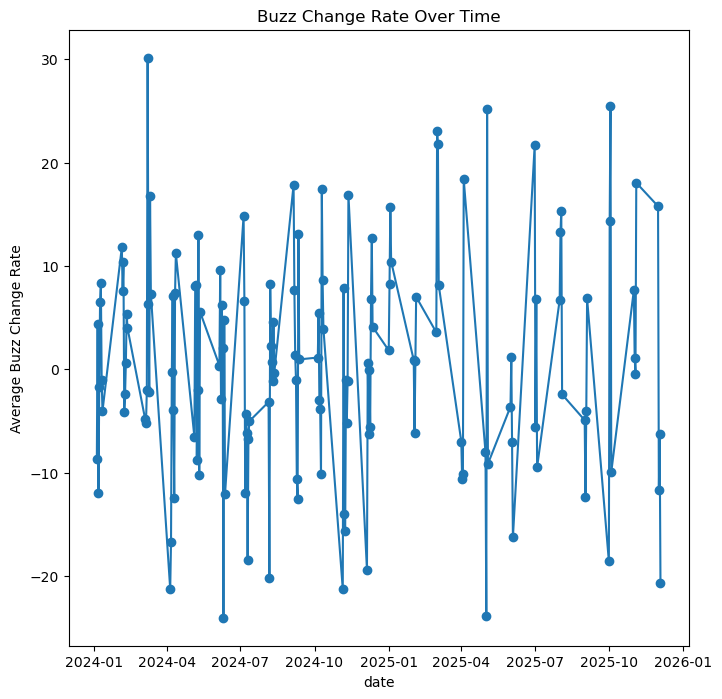

In [50]:
buzz_trend = df.groupby('date')['buzz_change_rate'].mean()
plt.figure(figsize=(8,8))
buzz_trend.plot(marker="o")
plt.title("Buzz Change Rate Over Time")
plt.ylabel("Average Buzz Change Rate")
plt.show()

𝗕𝘂𝘇𝘇 𝗖𝗵𝗮𝗻𝗴𝗲 𝗥𝗮𝘁𝗲 𝗢𝘃𝗲𝗿 𝗧𝗶𝗺𝗲
The buzz fluctuates heavily, with both sharp spikes and sudden drops.
Positive spikes indicate viral posts or trending hashtags, while negative drops suggest loss of attention or negative sentiment.

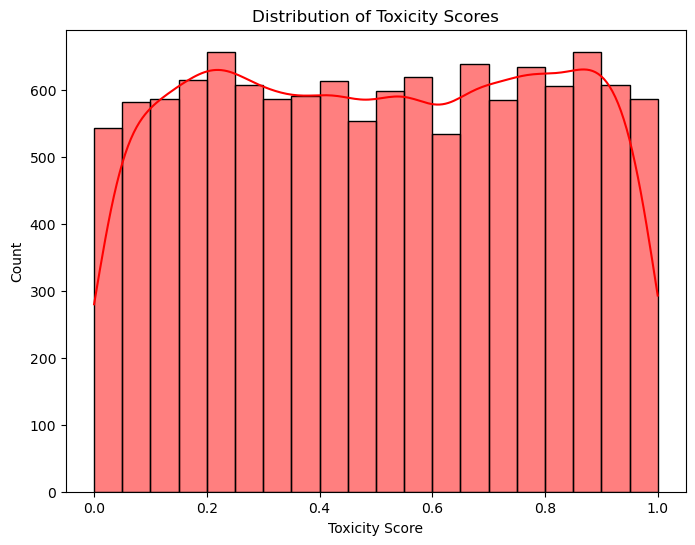

In [51]:
plt.figure(figsize=(8,6))
sns.histplot(df['toxicity_score'], bins=20, kde=True, color="red")
plt.title("Distribution of Toxicity Scores")
plt.xlabel("Toxicity Score")
plt.show()

𝗗𝗶𝘀𝘁𝗿𝗶𝗯𝘂𝘁𝗶𝗼𝗻 𝗼𝗳 𝗧𝗼𝘅𝗶𝗰𝗶𝘁𝘆 𝗦𝗰𝗼𝗿𝗲𝘀
Toxicity is spread fairly evenly across the dataset (0 to 1).
The dataset contains both highly positive and highly toxic posts, meaning brands face a wide spectrum of audience reactions.


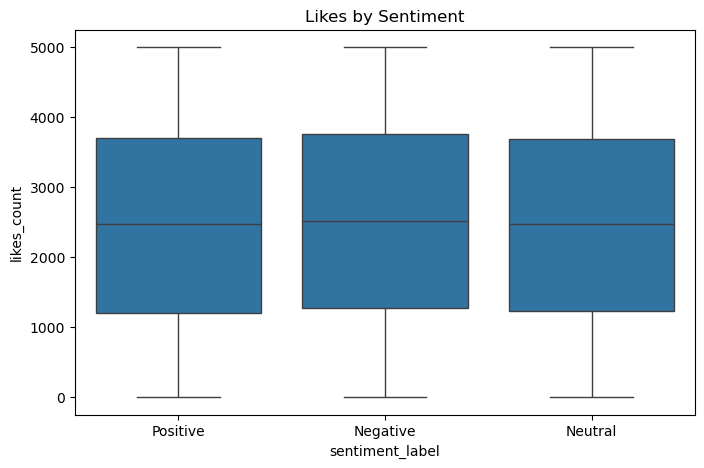

In [52]:
plt.figure(figsize=(8,5))
sns.boxplot(x='sentiment_label', y='likes_count', data=df)
plt.title("Likes by Sentiment")
plt.show()

𝗟𝗶𝗸𝗲𝘀 𝗯𝘆 𝗦𝗲𝗻𝘁𝗶𝗺𝗲𝗻𝘁
Posts with Positive, Negative, and Neutral sentiments all get roughly the same amount of likes on average, and the spread of likes is also similar. 
Sentiment doesn’t strongly drive likes_count here.
Negative posts sometimes attract as much engagement as positive ones, showing that controversial content can drive high visibility.
Neutral posts tend to stay consistent but less viral compared to strong sentiments.

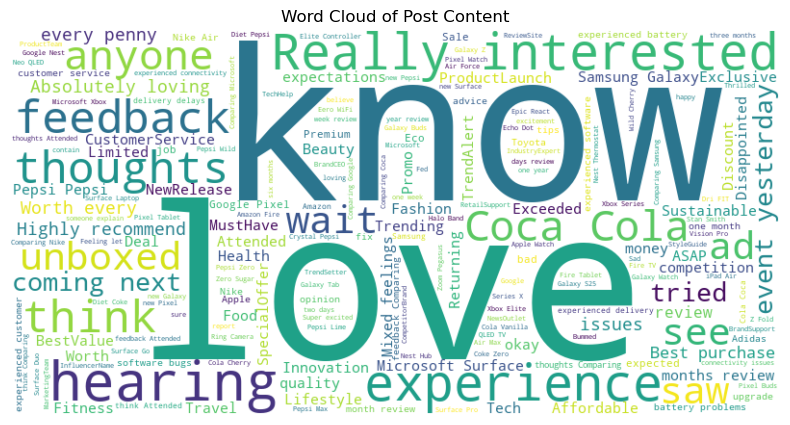

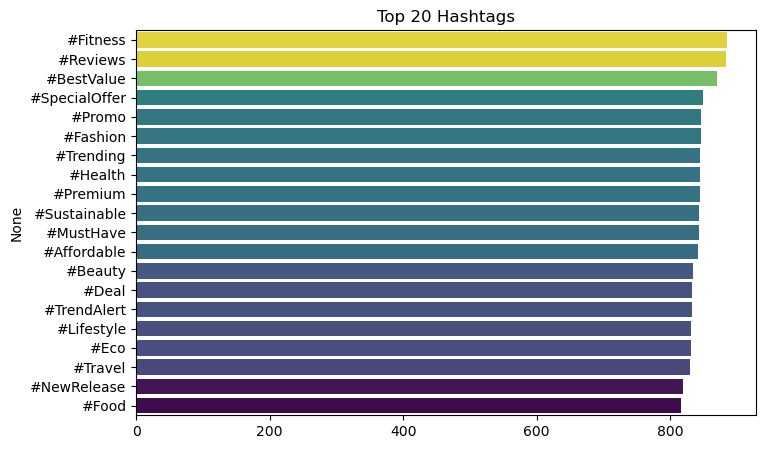

In [53]:


# WordCloud for text content
text_data = " ".join(df['text_content'].dropna().astype(str))
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text_data)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Post Content")
plt.show()

# Hashtag frequency
df['hashtags'] = df['hashtags'].fillna("").astype(str)
all_hashtags = " ".join(df['hashtags']).replace(",", " ").split()
hashtag_freq = pd.Series(all_hashtags).value_counts().head(20)

plt.figure(figsize=(8,5))
sns.barplot(x=hashtag_freq.values, y=hashtag_freq.index,hue= hashtag_freq.values,palette="viridis",legend=False)
plt.title("Top 20 Hashtags")
plt.show()


𝗪𝗼𝗿𝗱 𝗖𝗹𝗼𝘂𝗱 𝗼𝗳 𝗣𝗼𝘀𝘁 𝗖𝗼𝗻𝘁𝗲𝗻𝘁
Common words: love, know, feedback, experience, interested, really.
This shows users share opinions, experiences, and feedback—both positive and negative.
Keywords around brands (Pepsi, Samsung, Coca Cola) highlight how product launches & campaigns dominate buzz.

𝗧𝗼𝗽 𝟮𝟬 𝗛𝗮𝘀𝗵𝘁𝗮𝗴𝘀
Popular tags include #Fitness, #Reviews, #BestValue, #SpecialOffer, #Promo.
These show that lifestyle, product reviews, and discounts are key drivers of engagement.
Campaign-related hashtags (#NewRelease, #TrendAlert, #Sustainable) also stand out, linking directly to marketing events.


𝗣𝗿𝗼𝗷𝗲𝗰𝘁 𝗜𝗻𝘀𝗶𝗴𝗵𝘁𝘀
The analysis revealed that 𝑰𝒏𝒔𝒕𝒂𝒈𝒓𝒂𝒎 𝒂𝒏𝒅 𝑭𝒂𝒄𝒆𝒃𝒐𝒐𝒌 𝒅𝒓𝒊𝒗𝒆 𝒕𝒉𝒆 𝒉𝒊𝒈𝒉𝒆𝒔𝒕 𝒆𝒏𝒈𝒂𝒈𝒆𝒎𝒆𝒏𝒕 𝒓𝒂𝒕𝒆𝒔, while Twitter consistently lags behind. 𝑬𝒏𝒈𝒂𝒈𝒆𝒎𝒆𝒏𝒕  is not
uniform  across time—𝒑𝒐𝒔𝒕𝒊𝒏𝒈 𝒅𝒂𝒚 𝒂𝒏𝒅 𝒉𝒐𝒖𝒓 𝒔𝒊𝒈𝒏𝒊𝒇𝒊𝒄𝒂𝒏𝒕𝒍𝒚 𝒊𝒏𝒇𝒍𝒖𝒆𝒏𝒄𝒆 𝒑𝒆𝒓𝒇𝒐𝒓𝒎𝒂𝒏𝒄𝒆, with certain time slots consistently producing higher interaction.
Campaign dynamics also matter: 𝑷𝒓𝒆-𝑳𝒂𝒖𝒏𝒄𝒉 𝒄𝒂𝒎𝒑𝒂𝒊𝒈𝒏𝒔 𝒂𝒄𝒉𝒊𝒆𝒗𝒆𝒅 𝒔𝒕𝒓𝒐𝒏𝒈𝒆𝒓 𝒆𝒏𝒈𝒂𝒈𝒆𝒎𝒆𝒏𝒕  compared to Launch and Post-Launch phases, showing the importance of early audience excitement. Sentiment analysis highlighted that both 𝒑𝒐𝒔𝒊𝒕𝒊𝒗𝒆 𝒂𝒏𝒅 𝒏𝒆𝒈𝒂𝒕𝒊𝒗𝒆 𝒆𝒎𝒐𝒕𝒊𝒐𝒏𝒔 𝒄𝒂𝒏 𝒅𝒓𝒊𝒗𝒆 𝒆𝒏𝒈𝒂𝒈𝒆𝒎𝒆𝒏𝒕  though managing toxic content  remains critical. Finally, hashtag trends such as #𝑭𝒊𝒕𝒏𝒆𝒔𝒔, #𝑹𝒆𝒗𝒊𝒆𝒘𝒔, 𝒂𝒏𝒅 #𝑺𝒑𝒆𝒄𝒊𝒂𝒍𝑶𝒇𝒇𝒆𝒓  emerged as strong engagement boosters, pointing to the value of lifestyle, user feedback, and promotional content.

In [54]:
df.to_csv('Social Media Engagement Analysis.csv',  index= False)

In [55]:
df.to_csv(r"C:\Users\KHUSHBU MAGAR\Desktop\BHAGYASHRRE\CSV Analysis file\Social Media Engagement Analysis.csv", index=False)  